## D2D example: CLD on Social Norms in Obesity
In this example, we  implement a system dynamics model (SDM) analysis of a causal loop diagram (CLD) published by Crielaard et al (2020) doi: 10.1111/obr.13044. 

The diagram looks as follows:

<img src="Social_norms_CLD.jpg" alt="drawing" width="800"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [6]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Social_norms"  # Specify the relevant name of the CLD (Excel and json file should match this name)  
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 100  # Number of simulations
s.t_end = 12  # Timeframe of the simulation
s.time_unit = "Months"  # Base unit of time (time unit of t_end and dt)
s.prior = "uniform"  # "uniform" or "halfnormal"
s.parameter_value = 0.15  # Max range for uniform, SD for halfnormal

sdm = SDM(s)  # Load the module for formulating and simulating the SDM

Variable of interest: BMI
with 5 intervention variables

2 feedback loops of maximum length 5
All loops have at least one stock


Given these settings, we can now run simulations from the SDM-converted CLD.

In [7]:
df_sol, param_samples, eig_val_vec = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

Running Simulations: 100%|██████████| 100/100 [00:36<00:00,  2.77it/s]


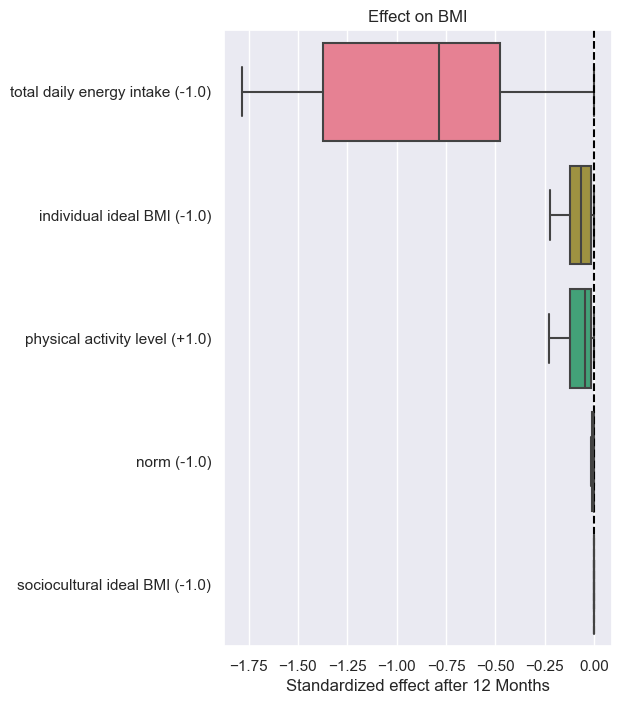

In [8]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi],
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

In [9]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")


---- Variable of Interest:  BMI

Comparison Table (Percentage Greater & Cliff’s Delta):
+---------------------------+-------------------------+-------------+-----------------+
| Intervention A            | Intervention B          |   % Greater |   Cliff's Delta |
+===========================+=========================+=============+=================+
| total_daily_energy_intake | individual_ideal_BMI    |         100 |            1    |
+---------------------------+-------------------------+-------------+-----------------+
| total_daily_energy_intake | physical_activity_level |          95 |            0.9  |
+---------------------------+-------------------------+-------------+-----------------+
| total_daily_energy_intake | norm                    |         100 |            1    |
+---------------------------+-------------------------+-------------+-----------------+
| total_daily_energy_intake | sociocultural_ideal_BMI |         100 |            1    |
+---------------------------+---

## Sensitivity analysis

In [10]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.01 #0.05
int_var = None  # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")

---- Variable of Interest:  BMI
+---------------------------------------------------------+----------------------+---------+
|                        Variable                         | Spearman correlation | p-value |
+---------------------------------------------------------+----------------------+---------+
|             total_daily_energy_intake->BMI              |         0.18         |   0.0   |
|     individual_ideal_BMI->total_daily_energy_intake     |         0.15         |  0.001  |
| physical_activity_level->total_daily_energy_expenditure |         0.14         |  0.001  |
|           total_daily_energy_expenditure->BMI           |         0.06         |  0.192  |
|  basal_metabolic_rate->total_daily_energy_expenditure   |         0.06         |  0.218  |
|      individual_ideal_BMI->physical_activity_level      |         0.05         |  0.28   |
|                BMI->basal_metabolic_rate                |         0.05         |  0.296  |
|                  grouplevel_BMI->nor